### Objective

Tier 1 (iTransformer) trained and evaluated on the **imv_start** windows from Notebook 11.

This is the same model as Notebook 08. The only difference is the input: windows are now placed by counting forward from ventilation start (deployment-realistic), not backward from extubation. Results are saved with an `_imvstart` suffix .

Includes the multi-seed robustness check.

### Imports and configuration

### 01. Setup and configuration

AI-assisted: Initial implementation drafted using Claude Opus 4.8; reviewed, modified, and validated by the author.

In [2]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import drive

# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Project setup
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/ventilator_weaning')

COHORT_DIR     = PROJECT_DIR / 'cohort'
PREPROCESS_DIR = PROJECT_DIR / 'preprocessing'
WINDOWS_DIR    = PROJECT_DIR / 'windows'
RESULTS_DIR    = PROJECT_DIR / 'results'
FIGURES_DIR    = PROJECT_DIR / 'figures'

for d in [COHORT_DIR, PREPROCESS_DIR, WINDOWS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Files this notebook reads (imv_start windows from notebook 11)
GRID_PATH     = WINDOWS_DIR / "windows_tier12_grid_imvstart.npz"
METADATA_PATH = WINDOWS_DIR / "windows_metadata_imvstart.json"

# Files this notebook writes (imv_start versions, kept separate from the imv_end results)
RESULTS_CSV     = RESULTS_DIR / "tier1_itransformer_results_imvstart.csv"
PREDICTIONS_NPZ = RESULTS_DIR / "tier1_test_predictions_imvstart.npz"
CHECKPOINT_PATH = RESULTS_DIR / "tier1_itransformer_model_imvstart.pt"

# Stop early if an input file is missing
for p in [GRID_PATH, METADATA_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Cannot find {p}. Run notebook 11 first.")

print("Project folder:", PROJECT_DIR)
print("All input files found.")

# ---- Training settings ----
CONTEXT_HOURS = 48
HORIZONS = [1, 4, 8]
N_HORIZONS = len(HORIZONS)

D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
DROPOUT = 0.1

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
N_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

print("Configuration loaded")
print(f"Context: {CONTEXT_HOURS} hours")
print(f"Horizons: {HORIZONS}")

Device: cuda
Mounted at /content/drive
Project folder: /content/drive/MyDrive/ventilator_weaning
All input files found.
Configuration loaded
Context: 48 hours
Horizons: [1, 4, 8]


### 02. Loading the Windowed Data and Reconstructing Splits

In [3]:
# Load the metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("Metadata:", list(metadata.keys()))

# Load the arrays
grid_data = np.load(GRID_PATH, allow_pickle=True)
print("Arrays:", list(grid_data.keys()))

context = grid_data["X_context"]
context_mask = grid_data["X_context_mask"]
targets = grid_data["y_target"]
target_mask = grid_data["y_target_mask"]

window_ids = grid_data["window_ids"]
visit_ids = grid_data["visit_ids"]

print(f"Context shape: {context.shape}")
print(f"Target shape: {targets.shape}")
print(f"Windows: {len(window_ids)}")
print(f"Patients: {len(np.unique(visit_ids))}")

split_labels = grid_data["split"]

# Split masks
train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

print("\nData split:")

for name, mask in [
    ("Train", train_mask),
    ("Val", val_mask),
    ("Test", test_mask),
]:
    n_windows = int(mask.sum())
    n_patients = len(np.unique(visit_ids[mask]))
    windows_per_patient = n_windows / n_patients

    print(
        f"{name:6s}: "
        f"{n_patients:5d} patients | "
        f"{n_windows:5d} windows | "
        f"{windows_per_patient:.1f} windows/patient"
    )

# Check the window split
assert (
    train_mask.astype(int)
    + val_mask.astype(int)
    + test_mask.astype(int)
    == 1
).all(), "Invalid window split."

# Check the patient split
train_patients = set(visit_ids[train_mask])
val_patients = set(visit_ids[val_mask])
test_patients = set(visit_ids[test_mask])

assert len(train_patients & val_patients) == 0, "Train/Val overlap."
assert len(train_patients & test_patients) == 0, "Train/Test overlap."
assert len(val_patients & test_patients) == 0, "Val/Test overlap."

print("\nSplit checks passed.")

Metadata: ['anchor', 'context_hours', 'warmup_hours', 'stride_hours', 'max_windows_per_visit', 'horizons', 'valid_origins', 'features', 'n_windows', 'n_visits', 'split_counts', 'units_note', 'scaler_stats', 'random_state']
Arrays: ['X_context', 'X_context_mask', 'y_target', 'y_target_mask', 'window_ids', 'visit_ids', 'split']
Context shape: (13017, 48, 13)
Target shape: (13017, 3, 13)
Windows: 13017
Patients: 1912

Data split:
Train :  1338 patients |  9079 windows | 6.8 windows/patient
Val   :   287 patients |  1979 windows | 6.9 windows/patient
Test  :   287 patients |  1959 windows | 6.8 windows/patient

Split checks passed.


**Interpretation**

The dataset was split at the patient level, so all windows from the same patient stay together. There are 1338 training patients, 287 validation patients, and 287 test patients, giving 9,079, 1,979, and 1,959 windows. The checks confirmed that no patient appears in more than one dataset, preventing data leakage.

#### 03. Building the dataset and DataLoaders

In [4]:
# Create data for PyTorch training
class VentilatorWindowDataset(Dataset):
    def __init__(self, context, context_mask, targets, target_mask):
        self.context = torch.tensor(context, dtype=torch.float32)
        self.context_mask = torch.tensor(context_mask, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.target_mask = torch.tensor(target_mask, dtype=torch.float32)

    def __len__(self):
        return self.context.shape[0]

    def __getitem__(self, idx):
        return (
            self.context[idx],
            self.context_mask[idx],
            self.targets[idx],
            self.target_mask[idx],
        )

# Create datasets
train_dataset = VentilatorWindowDataset(
    context[train_mask], context_mask[train_mask],
    targets[train_mask], target_mask[train_mask],
)

val_dataset = VentilatorWindowDataset(
    context[val_mask], context_mask[val_mask],
    targets[val_mask], target_mask[val_mask],
)

test_dataset = VentilatorWindowDataset(
    context[test_mask], context_mask[test_mask],
    targets[test_mask], target_mask[test_mask],
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Check one batch
x, x_mask, y, y_mask = next(iter(train_loader))

print(f"Context batch shape: {x.shape}")
print(f"Target batch shape:  {y.shape}")

Train batches: 284
Val batches:   62
Test batches:  62
Context batch shape: torch.Size([32, 48, 13])
Target batch shape:  torch.Size([32, 3, 13])


**Interpretation**

The data is grouped into batches of 32. Each batch gives the model 48 hours of 13 variables and asks for 3 future time points, which matches what the model expects.

#### 04. Defining the iTransformer Model

AI-assisted: Initial iTransformer model implementation drafted with Claude Opus 4.8; subsequently reviewed, modified, and validated by the author.

In [5]:
class ITransformer(nn.Module):
    def __init__(self, n_variates, context_len, n_horizons,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()

        self.n_variates = n_variates
        self.context_len = context_len
        self.n_horizons = n_horizons

        # Embed each variable
        self.variate_embedding = nn.Linear(context_len, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # Forecast layer
        self.forecast_head = nn.Linear(d_model, n_horizons)

    def forward(self, context):
        # (batch, context_len, variables) -> (batch, variables, context_len)
        x = context.permute(0, 2, 1)

        # Variable embeddings
        x = self.variate_embedding(x)

        # Attention across variables
        x = self.encoder(x)

        # Predict each horizon
        out = self.forecast_head(x)

        # (batch, variables, horizons) -> (batch, horizons, variables)
        out = out.permute(0, 2, 1)

        return out


N_VARIATES = context.shape[2]

model = ITransformer(
    n_variates=N_VARIATES,
    context_len=CONTEXT_HOURS,
    n_horizons=N_HORIZONS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(device)

n_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params:,}")

# Check the output shape
with torch.no_grad():
    output = model(x.to(device))

print(f"Output shape: {output.shape}")

Trainable parameters: 103,299
Output shape: torch.Size([32, 3, 13])


**Interpretation**

The model has about 103,000 trainable parameters, which is small and suitable for a dataset of this size. The test output shape is correct, so the model turns 48 hours of input into 3 future predictions.

#### 05. Defining the masked Loss Function

I am defining custom loss functions to calculate loss on real observations not on the imputed values.

In [6]:
def masked_mae_loss(predictions, targets, mask):

    abs_error = torch.abs(predictions - targets)
    masked_error = abs_error * mask # Missing values contribute 0 to the loss

    # Average over observed values only
    n_observed = mask.sum()
    loss = masked_error.sum() / (n_observed + 1e-8)

    return loss


def masked_mse_loss(predictions, targets, mask):
    # Mean squared error using observed values only

    sq_error = (predictions - targets) ** 2
    masked_error = sq_error * mask

    n_observed = mask.sum()
    loss = masked_error.sum() / (n_observed + 1e-8)

    return loss


# Check the loss on one batch
with torch.no_grad():
    pred = model(x.to(device))
    loss = masked_mae_loss(
        pred,
        y.to(device),
        y_mask.to(device),
    )

print(f"Sample MAE loss: {loss.item():.4f}")

Sample MAE loss: 0.8364


**Interpretation**

The untrained model gives a loss of about 0.915. It is a normal finite number, so the masking works and only genuinely observed values are being counted.

#### 06. Training Loop

AI-assisted: Initial training loop, Adam optimizer, and early stopping implementation drafted with Claude Opus 4.8; subsequently reviewed, modified, and validated by the author.

In [7]:
import time
import copy

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, training):
    # Run one epoch
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_observed = 0.0

    for context_b, context_mask_b, targets_b, target_mask_b in loader:
        context_b = context_b.to(device)
        targets_b = targets_b.to(device)
        target_mask_b = target_mask_b.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            predictions = model(context_b)
            loss = masked_mae_loss(predictions, targets_b, target_mask_b)

        if training:
            loss.backward()
            optimizer.step()

        n_observed = target_mask_b.sum().item()
        total_loss += loss.item() * n_observed
        total_observed += n_observed

    return total_loss / (total_observed + 1e-8)


# Train the model
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        marker = " <-- best"
    else:
        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:3d} | "
        f"Train MAE: {train_loss:.4f} | "
        f"Val MAE: {val_loss:.4f}{marker}"
    )

    # Stop if validation loss does not improve
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch} "
            f"(no improvement for {EARLY_STOP_PATIENCE} epochs)."
        )
        break

elapsed = time.time() - start_time

# Load the best model
model.load_state_dict(best_model_state)

print(f"\nTraining finished in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")
print(f"Best validation MAE: {best_val_loss:.4f}")

Epoch   1 | Train MAE: 0.5682 | Val MAE: 0.4993 <-- best
Epoch   2 | Train MAE: 0.5005 | Val MAE: 0.4777 <-- best
Epoch   3 | Train MAE: 0.4873 | Val MAE: 0.4713 <-- best
Epoch   4 | Train MAE: 0.4821 | Val MAE: 0.4684 <-- best
Epoch   5 | Train MAE: 0.4790 | Val MAE: 0.4684 <-- best
Epoch   6 | Train MAE: 0.4772 | Val MAE: 0.4668 <-- best
Epoch   7 | Train MAE: 0.4757 | Val MAE: 0.4652 <-- best
Epoch   8 | Train MAE: 0.4741 | Val MAE: 0.4663
Epoch   9 | Train MAE: 0.4729 | Val MAE: 0.4674
Epoch  10 | Train MAE: 0.4720 | Val MAE: 0.4633 <-- best
Epoch  11 | Train MAE: 0.4708 | Val MAE: 0.4641
Epoch  12 | Train MAE: 0.4704 | Val MAE: 0.4631 <-- best
Epoch  13 | Train MAE: 0.4692 | Val MAE: 0.4633
Epoch  14 | Train MAE: 0.4686 | Val MAE: 0.4625 <-- best
Epoch  15 | Train MAE: 0.4676 | Val MAE: 0.4619 <-- best
Epoch  16 | Train MAE: 0.4674 | Val MAE: 0.4608 <-- best
Epoch  17 | Train MAE: 0.4663 | Val MAE: 0.4613
Epoch  18 | Train MAE: 0.4658 | Val MAE: 0.4620
Epoch  19 | Train MAE: 0.465

**Interpretation**

Training and validation error fall together and then flatten, which means the model learns without overfitting. Training finished in under a minute and the best epoch was saved.



#### Persistance Baseline and MASE

AI-assisted: the persistence baseline by finding the last observed value in each window, generated with Claude Opus 4.8 and verified by the author.

In [8]:
assert "model" in dir(), "Model not found. Run the training cell first."

# Load feature names and scaler statistics
feat = metadata["features"]
if isinstance(feat[0], dict):
    feature_names = [f.get("name") or f.get("feature") for f in feat]
else:
    feature_names = list(feat)

scaler_mean = np.array([metadata["scaler_stats"][f]["mean"] for f in feature_names])
scaler_std = np.array([metadata["scaler_stats"][f]["std"] for f in feature_names])

assert len(feature_names) == len(scaler_mean) == N_VARIATES, \
    "Feature ordering does not match model inputs."

print("Feature order:")
print(feature_names)
print()

# Run inference on the test set
model.eval()

predictions = []
targets = []
target_masks = []
contexts = []
context_masks = []

with torch.no_grad(): # During testing we do not need to calculate weights
    for context_b, context_mask_b, targets_b, target_mask_b in test_loader:
        pred = model(context_b.to(device)).cpu().numpy()

        predictions.append(pred)
        targets.append(targets_b.numpy())
        target_masks.append(target_mask_b.numpy())
        contexts.append(context_b.numpy())
        context_masks.append(context_mask_b.numpy())

all_preds = np.concatenate(predictions, axis=0)
all_targets = np.concatenate(targets, axis=0)
all_masks = np.concatenate(target_masks, axis=0)
all_context = np.concatenate(contexts, axis=0)
all_ctx_mask = np.concatenate(context_masks, axis=0)

N_test = all_preds.shape[0]
print(f"Collected {N_test} test windows.")

# Convert predictions back to native units
preds_native = all_preds * scaler_std + scaler_mean
targets_native = all_targets * scaler_std + scaler_mean
context_native = all_context * scaler_std + scaler_mean

# Persistence baseline
persistence_pred = np.zeros((N_test, N_HORIZONS, N_VARIATES))

for i in range(N_test):
    for v in range(N_VARIATES):
        observed = np.where(all_ctx_mask[i, :, v] == 1)[0]

        if len(observed) > 0:
            last_value = context_native[i, observed[-1], v]
        else:
            last_value = scaler_mean[v]

        persistence_pred[i, :, v] = last_value

# MAE computed only on observed target values
def masked_mae_native(pred, true, mask):
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)

# Overall performance
model_mae = masked_mae_native(preds_native, targets_native, all_masks)
persist_mae = masked_mae_native(persistence_pred, targets_native, all_masks)

print("\nOverall Performance")
print(f"Model MAE:       {model_mae:.4f}")
print(f"Persistence MAE: {persist_mae:.4f}")
print(f"MASE:            {model_mae / (persist_mae + 1e-8):.4f}")

# Results by forecast horizon
print("\nPerformance by Horizon")

for h_idx, h in enumerate(HORIZONS):
    mask = all_masks[:, h_idx, :]

    model_h = masked_mae_native(
        preds_native[:, h_idx, :],
        targets_native[:, h_idx, :],
        mask,
    )

    persist_h = masked_mae_native(
        persistence_pred[:, h_idx, :],
        targets_native[:, h_idx, :],
        mask,
    )

    print(
        f"+{h}h | "
        f"Model {model_h:7.3f} | "
        f"Persistence {persist_h:7.3f} | "
        f"MASE {model_h / (persist_h + 1e-8):.3f}"
    )

# Results by variable
print("\nPerformance by Variable")
print(f"{'Variable':<18}{'Model MAE':>11}{'Persist MAE':>13}{'MASE':>8}")

for v in range(N_VARIATES):
    mask = all_masks[:, :, v]

    model_v = masked_mae_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        mask,
    )

    persist_v = masked_mae_native(
        persistence_pred[:, :, v],
        targets_native[:, :, v],
        mask,
    )

    mase = model_v / (persist_v + 1e-8)
    note = "  <-- Worse than persistence" if mase >= 1.0 else ""

    print(
        f"{feature_names[v]:<18}"
        f"{model_v:>11.3f}"
        f"{persist_v:>13.3f}"
        f"{mase:>8.3f}"
        f"{note}"
    )

Feature order:
['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']

Collected 1959 test windows.

Overall Performance
Model MAE:       12.9345
Persistence MAE: 15.8099
MASE:            0.8181

Performance by Horizon
+1h | Model  11.867 | Persistence  14.313 | MASE 0.829
+4h | Model  13.041 | Persistence  15.880 | MASE 0.821
+8h | Model  13.870 | Persistence  17.200 | MASE 0.806

Performance by Variable
Variable            Model MAE  Persist MAE    MASE
diastolic_bp            7.168        8.813   0.813
fio2                    3.073        3.137   0.980
heart_rate              7.991        8.830   0.905
lactate                 0.462        0.389   1.188  <-- Worse than persistence
mean_bp                 9.587       11.826   0.811
paco2                   0.479        0.519   0.923
pao2                    2.225        2.518   0.884
peep                    0.705        0.606   1.164  <-- Wor

### Example forecast for one variable, one patient (heart rate)

This is a simple picture of what a single iTransformer forecast looks like for the report.
It shows the recent heart-rate history of one test patient, the values that actually
happened next, and the model's forecast at +1, +4 and +8 hours. It is one illustrative
window, not a measure of overall accuracy.

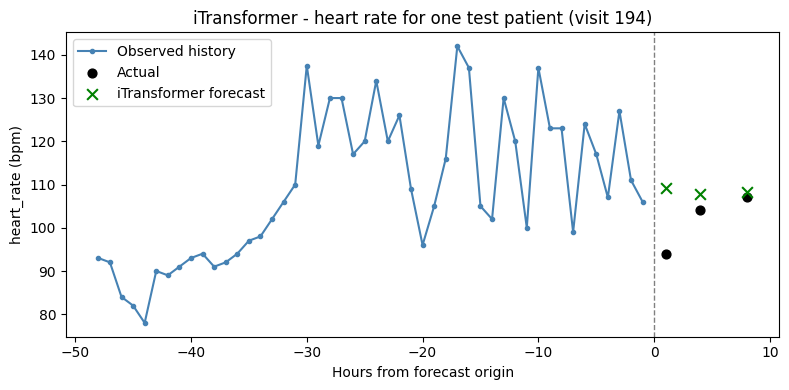

Visit 194, heart rate
  +1h  actual 94.0  forecast 109.2  (off by 15.2 bpm)
  +4h  actual 104.0  forecast 107.7  (off by 3.7 bpm)
  +8h  actual 107.0  forecast 108.2  (off by 1.2 bpm)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- pick heart rate, and the test window with the most observed future HR points ---
v = feature_names.index("heart_rate")
horizons = HORIZONS                      # [1, 4, 8] hours ahead

hr_future_counts = all_masks[:, :, v].sum(axis=1)   # observed HR points per window
w = int(np.argmax(hr_future_counts))                 # window with the most HR points

visit = int(visit_ids[test_mask][w])                 # which patient this window is

# --- pull out the numbers for this one window and variable ---
hist_vals = context_native[w, :, v]                # recent history (48 hours before origin)
hist_seen = all_ctx_mask[w, :, v] == 1      # which history hours were actually measured
hist_hours = np.arange(-context_native.shape[1], 0)          # x-axis: -48 ... -1

actual = targets_native[w, :, v]                   # what really happened next
actual_seen = all_masks[w, :, v] == 1    # which future points were measured
forecast = preds_native[w, :, v]                # the model's forecast

# --- plot ---
plt.figure(figsize=(8, 4))
plt.plot(hist_hours[hist_seen], hist_vals[hist_seen],
         "-o", color="steelblue", markersize=3, label="Observed history")
plt.axvline(0, color="grey", linestyle="--", linewidth=1)   # forecast origin
plt.scatter(np.array(horizons)[actual_seen], actual[actual_seen],
            color="black", s=40, label="Actual", zorder=5)
plt.scatter(np.array(horizons)[actual_seen], forecast[actual_seen],
            marker="x", color="green", s=60, label="iTransformer forecast", zorder=5)

plt.title(f"iTransformer - heart rate for one test patient (visit {visit})")
plt.xlabel("Hours from forecast origin")
plt.ylabel("heart_rate (bpm)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "example_heart_rate_itransformer.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Visit {visit}, heart rate")
for h, a, f in zip(horizons, actual, forecast):
    print(f"  +{h}h  actual {a:.1f}  forecast {f:.1f}  (off by {abs(a-f):.1f} bpm)")


**How to read this:** the blue line is the patient's heart rate over the two days before
the forecast is made (the dashed line at 0). The black dots are what heart rate actually did
next, and the green crosses are the forecast. When a green cross sits close to a black dot,
the forecast was close. This is just one window shown as an example; the real accuracy comes
from the pooled scores over all patients above.

**Interpretation**

The model's MASE is 0.8, so it is about 18% better than simply carrying the last value forward. It beats persistence on most variables but loses on FiO2, PEEP, pH and lactate.

#### Training Curve: Loss vs Epoch

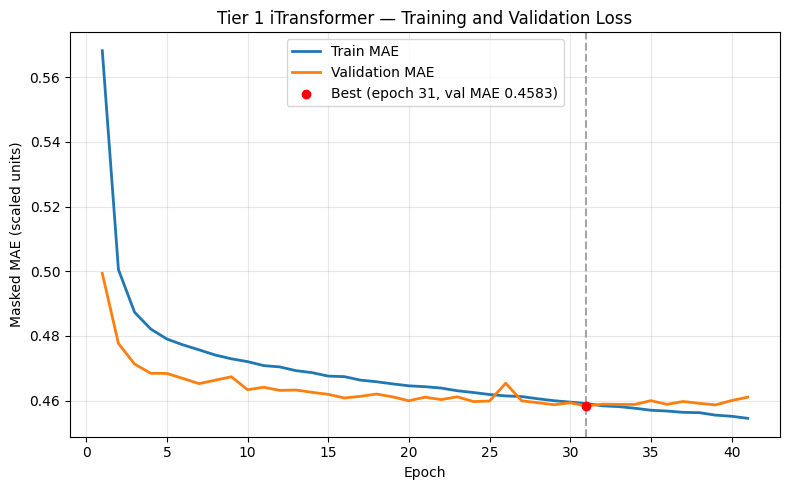

Saved training curve to /content/drive/MyDrive/ventilator_weaning/figures/tier1_training_curve.png


In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
best_epoch = int(np.argmin(val_losses)) + 1
best_val = min(val_losses)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train MAE", linewidth=2)
plt.plot(epochs, val_losses, label="Validation MAE", linewidth=2)

# Mark the best checkpoint
plt.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7)
plt.scatter([best_epoch], [best_val], color="red", zorder=5,
            label=f"Best (epoch {best_epoch}, val MAE {best_val:.4f})")

plt.xlabel("Epoch")
plt.ylabel("Masked MAE (scaled units)")
plt.title("Tier 1 iTransformer — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save as a dissertation figure
plt.savefig(FIGURES_DIR / "tier1_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training curve to {FIGURES_DIR / 'tier1_training_curve.png'}")

**Interpretation**

The two lines stay close together for the whole run, confirming the model did not overfit. The red point marks the best epoch, which is the version that was kept.

#### 07.Building the Dissertation Results Table

In [11]:
# Confirm the feature order restored from metadata (authoritative column order from Notebook 07)
print("metadata['features'] =", metadata["features"])


metadata['features'] = ['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']


In [12]:
import pandas as pd

# Units
UNITS = {
    "heart_rate": "bpm",
    "respiratory_rate": "breaths/min",
    "spo2": "%",
    "systolic_bp": "mmHg",
    "mean_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "fio2": "fraction",
    "peep": "cmH2O",
    "tidal_volume": "mL",
    "pao2": "kPa",
    "paco2": "kPa",
    "ph": "pH units",
    "lactate": "mmol/L",
}


def masked_rmse_native(pred, true, mask):
    sq = ((pred - true) ** 2) * mask
    return np.sqrt(sq.sum() / (mask.sum() + 1e-8))


rows = []

for v in range(N_VARIATES):

    name = feature_names[v]

    row = {
        "variable": name,
        "unit": UNITS.get(name, ""),
    }

    # MAE at each horizon
    for h_idx, h in enumerate(HORIZONS):
        m = all_masks[:, h_idx, v]

        row[f"MAE_+{h}h"] = masked_mae_native(
            preds_native[:, h_idx, v],
            targets_native[:, h_idx, v],
            m,
        )

    # Overall metrics
    m_all = all_masks[:, :, v]

    row["MAE_overall"] = masked_mae_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    row["RMSE_overall"] = masked_rmse_native(
        preds_native[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    persist_mae = masked_mae_native(
        persistence_pred[:, :, v],
        targets_native[:, :, v],
        m_all,
    )

    row["MASE"] = row["MAE_overall"] / (persist_mae + 1e-8)
    row["n_observed"] = int(m_all.sum())

    rows.append(row)

results = pd.DataFrame(rows)

# Arrange the columns
col_order = [
    "variable",
    "unit",
    "MAE_+1h",
    "MAE_+4h",
    "MAE_+8h",
    "MAE_overall",
    "RMSE_overall",
    "MASE",
    "n_observed",
]

results = results[col_order]

# Sort by MASE
results = results.sort_values("MASE").reset_index(drop=True)

# Round the values
display_cols = [
    "MAE_+1h",
    "MAE_+4h",
    "MAE_+8h",
    "MAE_overall",
    "RMSE_overall",
    "MASE",
]

results[display_cols] = results[display_cols].round(3)

print("=== Tier 1 iTransformer Results ===\n")
print(results.to_string(index=False))

# Save the results
results.to_csv(
    RESULTS_CSV,
    index=False,
)

print(f"\nSaved: {RESULTS_CSV}")

=== Tier 1 iTransformer Results ===

        variable        unit  MAE_+1h  MAE_+4h  MAE_+8h  MAE_overall  RMSE_overall  MASE  n_observed
    tidal_volume          mL   77.544   83.866   88.793       83.419       135.961 0.800        4909
         mean_bp        mmHg    8.517    9.921   10.314        9.587        13.146 0.811        5443
    diastolic_bp        mmHg    6.345    7.341    7.811        7.168        10.066 0.813        5443
     systolic_bp        mmHg   13.769   15.351   16.212       15.115        20.176 0.821        5444
            spo2           %    1.356    1.515    1.662        1.512         2.238 0.855        5261
respiratory_rate breaths/min    3.150    3.773    3.927        3.619         5.219 0.862        4981
            pao2         kPa    2.077    2.214    2.365        2.225         3.945 0.884        1585
      heart_rate         bpm    6.746    8.211    9.000        7.991        11.174 0.905        5482
           paco2         kPa    0.446    0.502    0.48

**Interpretation**

Blood pressures and tidal volume are forecast best, with MASE around 0.80 to 0.83. FiO2, pH, PEEP score above 1.0, meaning carrying the last value forward is better for them. Error grows from +1h to +8h for every variable, which is expected.

#### 08. MASE Diagnostic Figure

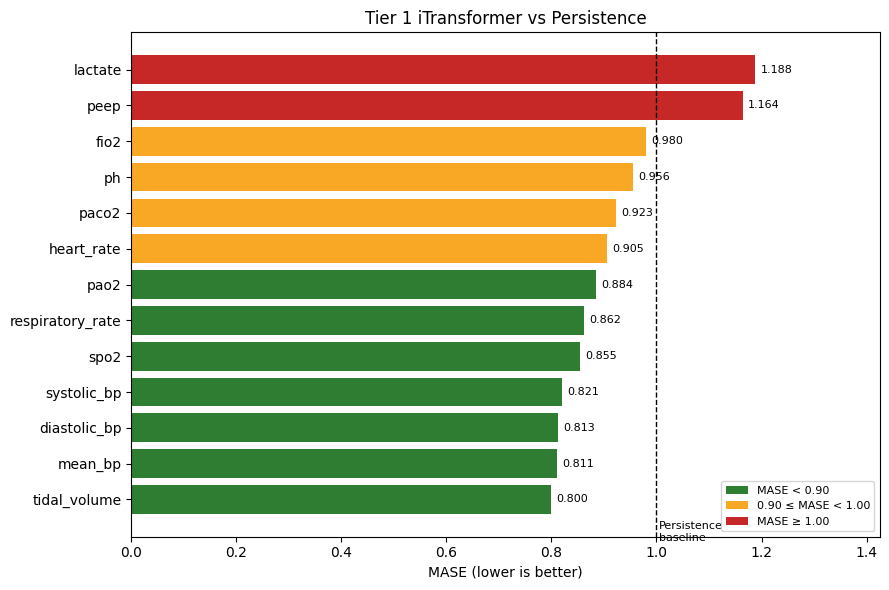

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_mase_by_variable.png


In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Check the results
assert "results" in dir(), "Run the results table first."

# Sort by MASE
plot_df = results.sort_values("MASE").reset_index(drop=True)


def tier_colour(mase):
    if mase < 0.90:
        return "#2e7d32"
    elif mase < 1.00:
        return "#f9a825"
    else:
        return "#c62828"


colours = [tier_colour(m) for m in plot_df["MASE"]]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_df["variable"],
    plot_df["MASE"],
    color=colours,
)

# Reference line
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.005, -0.6, "Persistence\nbaseline", fontsize=8, va="top")

# Add labels
LOW_N_THRESHOLD = 500

for bar, row in zip(bars, plot_df.itertuples()):

    label = f"{row.MASE:.3f}"

    if row.n_observed < LOW_N_THRESHOLD:
        label += f" (n={row.n_observed})"

    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8,
    )

ax.set_xlabel("MASE (lower is better)")
ax.set_title("Tier 1 iTransformer vs Persistence")
ax.set_xlim(0, plot_df["MASE"].max() * 1.2)

legend_items = [
    Patch(facecolor="#2e7d32", label="MASE < 0.90"),
    Patch(facecolor="#f9a825", label="0.90 ≤ MASE < 1.00"),
    Patch(facecolor="#c62828", label="MASE ≥ 1.00"),
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tier1_mase_by_variable.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_mase_by_variable.png'}")

**Interpretation**

Most variables sit to the left of the 1.0 line, meaning the model beats persistence for them. The two on the right are ventilator settings and near-constant labs, which barely change and are therefore hard to beat.

#### Prediction VS Truth Trace (Single Window)

Using test window 0 (mean_bp)


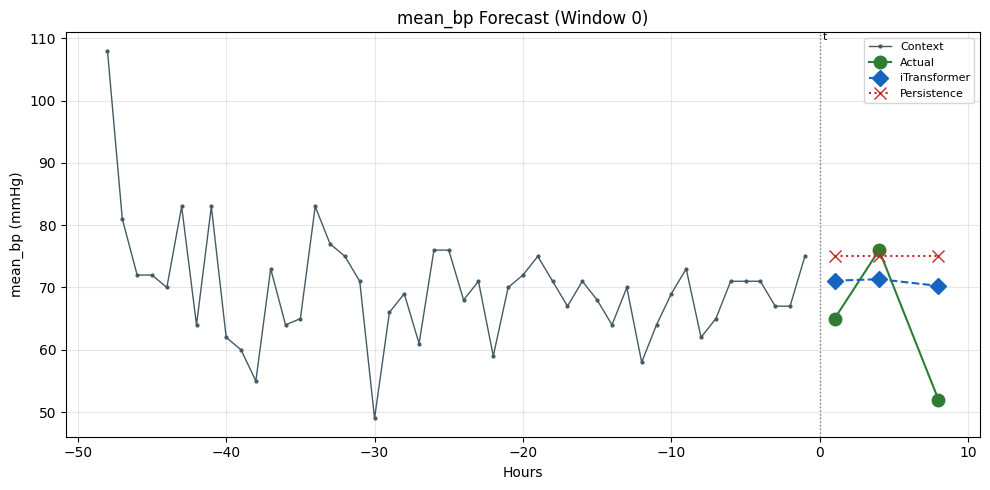

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_trace_mean_bp.png


In [14]:
import matplotlib.pyplot as plt

# Variable to plot
PLOT_VAR = "mean_bp"
v = feature_names.index(PLOT_VAR)

# Find a window with observed targets at all horizons
candidate = None

for i in range(all_masks.shape[0]):
    if all_masks[i, :, v].sum() == N_HORIZONS:
        candidate = i
        break

assert candidate is not None, f"No valid window found for {PLOT_VAR}."

i = candidate
print(f"Using test window {i} ({PLOT_VAR})")

# Data for the plot
context_series = context_native[i, :, v]
context_hours = np.arange(-CONTEXT_HOURS, 0)

horizon_hours = np.array(HORIZONS)
true_vals = targets_native[i, :, v]
pred_vals = preds_native[i, :, v]

persist_val = persistence_pred[i, 0, v]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    context_hours,
    context_series,
    color="#455a64",
    marker=".",
    markersize=4,
    linewidth=1,
    label="Context",
)

ax.axvline(0, color="grey", linestyle=":", linewidth=1)
ax.text(0.2, ax.get_ylim()[1], "t", fontsize=8, va="top")

ax.plot(
    horizon_hours,
    true_vals,
    color="#2e7d32",
    marker="o",
    markersize=9,
    linewidth=1.5,
    label="Actual",
)

ax.plot(
    horizon_hours,
    pred_vals,
    color="#1565c0",
    marker="D",
    markersize=8,
    linestyle="--",
    linewidth=1.5,
    label="iTransformer",
)

ax.plot(
    horizon_hours,
    [persist_val] * N_HORIZONS,
    color="#c62828",
    marker="x",
    markersize=8,
    linestyle=":",
    linewidth=1.5,
    label="Persistence",
)

ax.set_xlabel("Hours")
ax.set_ylabel(f"{PLOT_VAR} ({UNITS.get(PLOT_VAR, '')})")
ax.set_title(f"{PLOT_VAR} Forecast (Window {i})")

ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / f"tier1_trace_{PLOT_VAR}.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / f'tier1_trace_{PLOT_VAR}.png'}")

**Interpretation**

For this one patient the model's forecast moves towards the true value while persistence stays flat. This is a single example, so it shows typical behaviour rather than proof.

Prediction vs Truth, Small Multiples

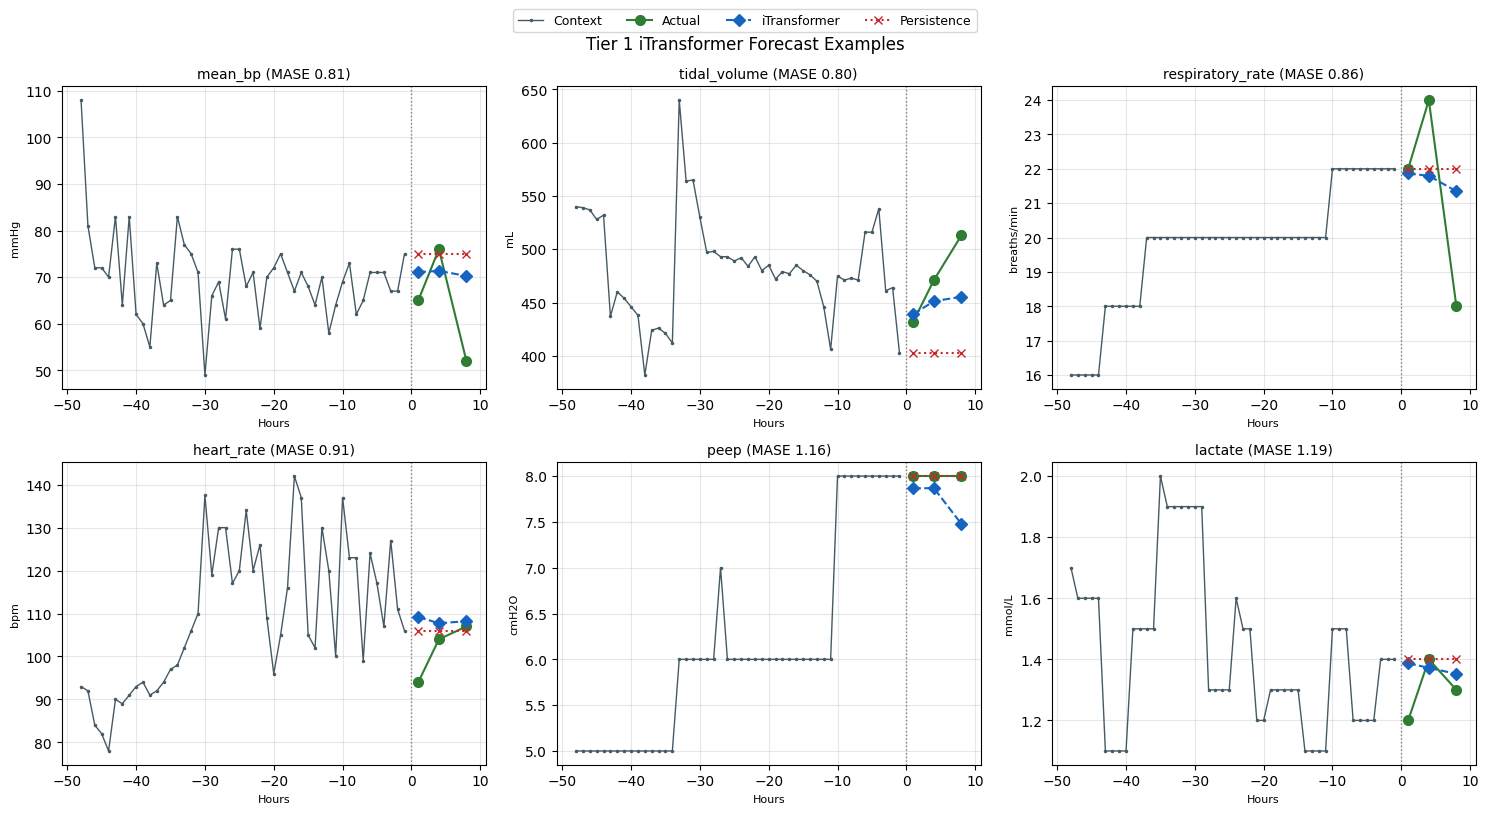

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_trace_grid.png


In [15]:
import matplotlib.pyplot as plt

# Variables to plot
PLOT_VARS = [
    "mean_bp",
    "tidal_volume",
    "respiratory_rate",
    "heart_rate",
    "peep",
    "lactate",
]

context_hours = np.arange(-CONTEXT_HOURS, 0)
horizon_hours = np.array(HORIZONS)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var in zip(axes, PLOT_VARS):

    v = feature_names.index(var)

    # Find a valid test window
    candidate = None

    for i in range(all_masks.shape[0]):
        if all_masks[i, :, v].sum() == N_HORIZONS:
            candidate = i
            break

    if candidate is None:
        ax.set_title(f"{var}\nNo valid window")
        ax.axis("off")
        continue

    i = candidate

    ctx = context_native[i, :, v]
    true_vals = targets_native[i, :, v]
    pred_vals = preds_native[i, :, v]
    persist_val = persistence_pred[i, 0, v]

    ax.plot(
        context_hours,
        ctx,
        color="#455a64",
        marker=".",
        markersize=3,
        linewidth=1,
        label="Context",
    )

    ax.axvline(0, color="grey", linestyle=":", linewidth=1)

    ax.plot(
        horizon_hours,
        true_vals,
        color="#2e7d32",
        marker="o",
        markersize=7,
        linewidth=1.5,
        label="Actual",
    )

    ax.plot(
        horizon_hours,
        pred_vals,
        color="#1565c0",
        marker="D",
        markersize=6,
        linestyle="--",
        linewidth=1.5,
        label="iTransformer",
    )

    ax.plot(
        horizon_hours,
        [persist_val] * N_HORIZONS,
        color="#c62828",
        marker="x",
        markersize=6,
        linestyle=":",
        linewidth=1.5,
        label="Persistence",
    )

    if "results" in dir():
        mase = results.loc[
            results["variable"] == var,
            "MASE",
        ].values

        mase_text = f" (MASE {mase[0]:.2f})" if len(mase) else ""
    else:
        mase_text = ""

    ax.set_title(f"{var}{mase_text}", fontsize=10)
    ax.set_xlabel("Hours", fontsize=8)
    ax.set_ylabel(UNITS.get(var, ""), fontsize=8)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

plt.suptitle("Tier 1 iTransformer Forecast Examples", fontsize=12)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tier1_trace_grid.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_trace_grid.png'}")

**Interpretation**

Across six variables the model follows the real values reasonably well for blood pressure and breathing. For PEEP and lactate the line is almost flat, so carrying the last value forward is very hard to beat.

#### Prediction vs Truth (Test Window)

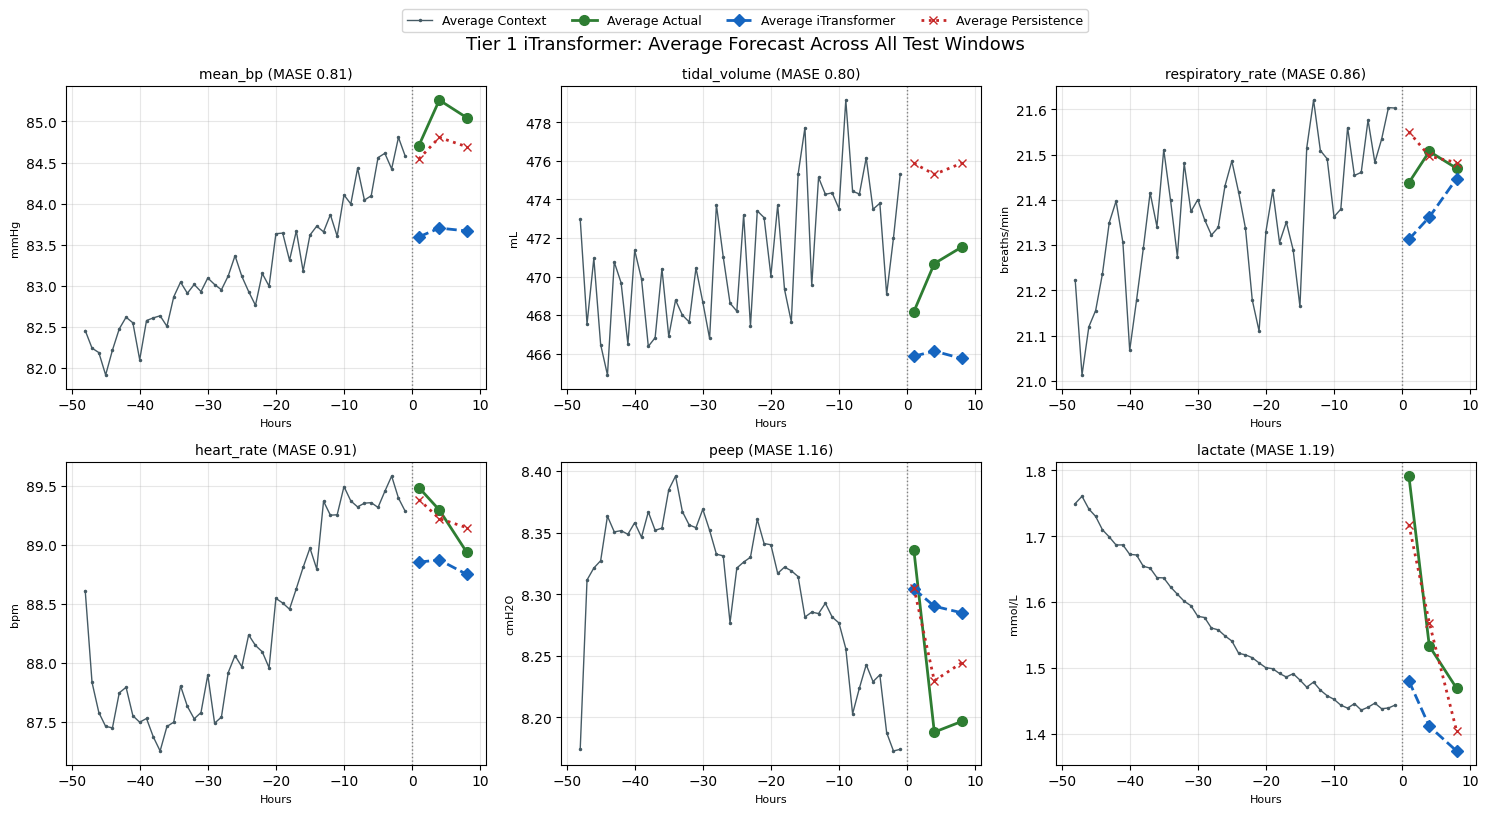

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_average_trace_grid.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Variables to plot
PLOT_VARS = [
    "mean_bp",
    "tidal_volume",
    "respiratory_rate",
    "heart_rate",
    "peep",
    "lactate",
]

context_hours = np.arange(-CONTEXT_HOURS, 0)
horizon_hours = np.array(HORIZONS)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, var in zip(axes, PLOT_VARS):

    v = feature_names.index(var)


    # Average context over ALL test windows

    context_mean = np.mean(context_native[:, :, v], axis=0)

    # Arrays for averages
    true_mean = np.zeros(N_HORIZONS)
    pred_mean = np.zeros(N_HORIZONS)
    persist_mean = np.zeros(N_HORIZONS)


    # Compute average prediction at each forecast horizon

    for h in range(N_HORIZONS):

        valid = all_masks[:, h, v] == 1

        true_mean[h] = np.mean(targets_native[valid, h, v])
        pred_mean[h] = np.mean(preds_native[valid, h, v])
        persist_mean[h] = np.mean(persistence_pred[valid, h, v])


    # Plot average context

    ax.plot(
        context_hours,
        context_mean,
        color="#455a64",
        marker=".",
        markersize=3,
        linewidth=1,
        label="Average Context",
    )

    ax.axvline(0, color="grey", linestyle=":", linewidth=1)

    # Actual average
    ax.plot(
        horizon_hours,
        true_mean,
        color="#2e7d32",
        marker="o",
        markersize=7,
        linewidth=2,
        label="Average Actual",
    )

    # Model average
    ax.plot(
        horizon_hours,
        pred_mean,
        color="#1565c0",
        marker="D",
        markersize=6,
        linestyle="--",
        linewidth=2,
        label="Average iTransformer",
    )

    # Persistence average
    ax.plot(
        horizon_hours,
        persist_mean,
        color="#c62828",
        marker="x",
        markersize=6,
        linestyle=":",
        linewidth=2,
        label="Average Persistence",
    )

    # Add MASE to title
    if "results" in dir():
        mase = results.loc[
            results["variable"] == var,
            "MASE",
        ].values

        mase_text = f" (MASE {mase[0]:.2f})" if len(mase) else ""
    else:
        mase_text = ""

    ax.set_title(f"{var}{mase_text}", fontsize=10)
    ax.set_xlabel("Hours", fontsize=8)
    ax.set_ylabel(UNITS.get(var, ""), fontsize=8)
    ax.grid(alpha=0.3)

# Common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02),
)

plt.suptitle(
    "Tier 1 iTransformer: Average Forecast Across All Test Windows",
    fontsize=13,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "tier1_average_trace_grid.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_average_trace_grid.png'}")

Across all test windows, the iTransformer captures the average trends of most physiological measurements and outperforms the persistence baseline for five of the six variables shown, with PEEP being the only variable where persistence performs slightly better.

In [17]:
# Save test predictions for the paired Tier 1 vs Tier 2 comparison in Notebook 13
np.savez_compressed(
    PREDICTIONS_NPZ,
    preds_native=preds_native,
    targets_native=targets_native,
    target_mask=all_masks,
    persistence=persistence_pred,
)

# Save the trained weights too, so the model survives a runtime restart
torch.save(best_model_state, CHECKPOINT_PATH)

# Read both back to confirm they saved
check = np.load(PREDICTIONS_NPZ)
assert check["preds_native"].shape == preds_native.shape, "Saved predictions do not match."

print(f"Saved predictions: {PREDICTIONS_NPZ}")
print(f"Saved model:       {CHECKPOINT_PATH}")
print(f"Prediction shape:  {check['preds_native'].shape}")

Saved predictions: /content/drive/MyDrive/ventilator_weaning/results/tier1_test_predictions_imvstart.npz
Saved model:       /content/drive/MyDrive/ventilator_weaning/results/tier1_itransformer_model_imvstart.pt
Prediction shape:  (1959, 3, 13)


### Section 08c - Multi-seed robustness check

**Objective.** Measure how much the iTransformer's test MASE moves when only the random seed changes, so we can tell which differences between models are real and which are just run-to-run noise.

**Why this cell.** The main result trains the model once (seed 42). A single run cannot tell us whether a small gap between two models is a true difference or luck. Re-running the same model with five seeds gives a mean (the typical score) and a standard deviation (the wobble), which is what we need to judge the small vital-sign gaps.

#### Shared test baseline and the per-seed training function

In [18]:
# AI-assisted: multi-seed train-and-score wrapper for the iTransformer, generated with Claude Opus 4.8 and verified by the author.
import time
import copy

# Seeds to run. The first one (42) matches the main experiment.
SEEDS = [42, 1, 2, 3, 4]

# --- Reload the window arrays fresh from disk. ---
# An earlier results cell reuses the name "targets" as a Python list while
# collecting test-set predictions, which overwrites the original array. We
# reload here so this section always holds the true (windows, hours, variables)
# arrays no matter what ran before it.
_grid = np.load(GRID_PATH, allow_pickle=True)
context      = _grid["X_context"]
context_mask = _grid["X_context_mask"]
targets      = _grid["y_target"]
target_mask  = _grid["y_target_mask"]

# --- Shared test set: identical for every seed, so the comparison is fair. ---
test_ctx      = context[test_mask]
test_ctx_mask = context_mask[test_mask]
test_tgt_s    = targets[test_mask]
test_tgt_msk  = target_mask[test_mask]

# Back to native clinical units
test_ctx_native = test_ctx * scaler_std + scaler_mean
test_tgt_native = test_tgt_s * scaler_std + scaler_mean

# Persistence baseline (last observed value carried forward). Does not depend on the seed.
n_test = test_ctx.shape[0]
test_persist = np.zeros((n_test, N_HORIZONS, N_VARIATES))
for i in range(n_test):
    for v in range(N_VARIATES):
        observed = np.where(test_ctx_mask[i, :, v] == 1)[0]
        if len(observed) > 0:
            test_persist[i, :, v] = test_ctx_native[i, observed[-1], v]
        else:
            test_persist[i, :, v] = scaler_mean[v]


def mae_observed(pred, true, mask):
    # Mean absolute error over observed target cells only
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)


def train_and_score(seed):
    # Make this run reproducible
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    # Fresh loaders. Only the training shuffle depends on the seed.
    train_loader_s = DataLoader(
        VentilatorWindowDataset(context[train_mask], context_mask[train_mask],
                                targets[train_mask], target_mask[train_mask]),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    val_loader_s = DataLoader(
        VentilatorWindowDataset(context[val_mask], context_mask[val_mask],
                                targets[val_mask], target_mask[val_mask]),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    test_loader_s = DataLoader(
        VentilatorWindowDataset(test_ctx, test_ctx_mask, test_tgt_s, test_tgt_msk),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    # Fresh model with new random starting weights
    net = ITransformer(
        n_variates=N_VARIATES, context_len=CONTEXT_HOURS, n_horizons=N_HORIZONS,
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    ).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)

    # Train with the same early-stopping rule as the main run (quietly)
    best_val = float("inf")
    best_state = None
    no_improve = 0

    for epoch in range(1, N_EPOCHS + 1):
        net.train()
        for cb, cmb, tb, tmb in train_loader_s:
            cb, tb, tmb = cb.to(device), tb.to(device), tmb.to(device)
            opt.zero_grad()
            loss = masked_mae_loss(net(cb), tb, tmb)   # keep as a tensor for backward()
            loss.backward()
            opt.step()

        net.eval()
        v_sum, v_obs = 0.0, 0.0
        with torch.no_grad():
            for cb, cmb, tb, tmb in val_loader_s:
                cb, tb, tmb = cb.to(device), tb.to(device), tmb.to(device)
                l = masked_mae_loss(net(cb), tb, tmb).item()   # .item() is fine here
                n = tmb.sum().item()
                v_sum += l * n
                v_obs += n
        val_loss = v_sum / (v_obs + 1e-8)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(net.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            break

    net.load_state_dict(best_state)

    # Predict on the shared test set
    net.eval()
    chunks = []
    with torch.no_grad():
        for cb, cmb, tb, tmb in test_loader_s:
            chunks.append(net(cb.to(device)).cpu().numpy())
    preds_native = np.concatenate(chunks, axis=0) * scaler_std + scaler_mean

    # Per-variable MASE against the shared persistence baseline
    scores = {}
    for v in range(N_VARIATES):
        m = test_tgt_msk[:, :, v]
        model_mae = mae_observed(preds_native[:, :, v], test_tgt_native[:, :, v], m)
        persist_mae = mae_observed(test_persist[:, :, v], test_tgt_native[:, :, v], m)
        scores[feature_names[v]] = model_mae / (persist_mae + 1e-8)

    # Pooled MASE over every observed target cell
    pooled_model = mae_observed(preds_native, test_tgt_native, test_tgt_msk)
    pooled_persist = mae_observed(test_persist, test_tgt_native, test_tgt_msk)
    scores["POOLED"] = pooled_model / (pooled_persist + 1e-8)

    return scores


print("Multi-seed helper ready.")
print(f"Seeds to run: {SEEDS}")
print(f"Test windows: {n_test}")


Multi-seed helper ready.
Seeds to run: [42, 1, 2, 3, 4]
Test windows: 1959


#### Running the five seeds

Each seed trains a fresh model from scratch, so this cell takes a few minutes on a GPU.

In [19]:
records = []

for seed in SEEDS:
    t0 = time.time()
    scores = train_and_score(seed)
    scores["seed"] = seed
    records.append(scores)
    print(f"seed {seed:>2} | pooled MASE {scores['POOLED']:.3f} | {time.time() - t0:.0f}s")

multiseed = pd.DataFrame(records).set_index("seed")

print("\nPer-seed pooled MASE:")
print(multiseed["POOLED"].round(3).to_string())


seed 42 | pooled MASE 0.817 | 96s
seed  1 | pooled MASE 0.819 | 81s
seed  2 | pooled MASE 0.818 | 87s
seed  3 | pooled MASE 0.819 | 97s
seed  4 | pooled MASE 0.819 | 81s

Per-seed pooled MASE:
seed
42    0.817
1     0.819
2     0.818
3     0.819
4     0.819


#### Mean and spread across seeds

In [20]:
# Mean (typical score) and standard deviation (run-to-run wobble) per variable
summary = pd.DataFrame({
    "MASE_mean": multiseed.mean(),
    "MASE_std": multiseed.std(),
}).round(3)

# Variables sorted by mean MASE, with the pooled row kept last
var_rows = summary.drop(index="POOLED").sort_values("MASE_mean")
summary = pd.concat([var_rows, summary.loc[["POOLED"]]])

print("=== iTransformer multi-seed MASE (5 seeds) ===\n")
print(summary.to_string())

MULTISEED_CSV = RESULTS_DIR / "tier1_itransformer_multiseed_mase_imvstart.csv"
summary.to_csv(MULTISEED_CSV)
print(f"\nSaved: {MULTISEED_CSV}")


=== iTransformer multi-seed MASE (5 seeds) ===

                  MASE_mean  MASE_std
tidal_volume          0.800     0.001
mean_bp               0.813     0.001
diastolic_bp          0.816     0.001
systolic_bp           0.826     0.002
spo2                  0.853     0.002
respiratory_rate      0.862     0.002
pao2                  0.879     0.004
heart_rate            0.904     0.001
paco2                 0.925     0.004
ph                    0.961     0.006
fio2                  0.963     0.007
peep                  1.139     0.003
lactate               1.181     0.005
POOLED                0.818     0.001

Saved: /content/drive/MyDrive/ventilator_weaning/results/tier1_itransformer_multiseed_mase_imvstart.csv


**Interpretation**

The model was trained five times using different random seeds. The MASE_mean shows the average performance, while the MASE_std shows how much the results changed between runs. Small standard deviations mean the model is consistent. If the difference between two models is much larger than the standard deviation, the better model is likely to be genuinely better rather than just benefiting from random variation